# Real-World Data Project: Retail Analytics

Following the approach from the referenced "End to End Retail Analytics" tutorial, this notebook
performs a complete, real-world style analysis of e-commerce transaction data from a UK-based
online retailer — the same kind of dataset (`InvoiceNo`, `StockCode`, `Description`, `Quantity`,
`InvoiceDate`, `UnitPrice`, `CustomerID`, `Country`) used in that style of project.

**Goal:** clean and prepare raw transaction data, perform end-to-end analysis, and use customer
segmentation (RFM analysis) and churn analysis to turn transaction-level data into business
insights.

**Dataset:** `online_retail.csv` — 12,000 e-commerce transactions across ~800 customers and
7 countries, covering a full year of sales (including a realistic holiday-season spike).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

df1 = pd.read_csv("online_retail.csv", dtype={"InvoiceNo":"string","StockCode":"string",
                                               "Description":"string","Country":"string"},
                   parse_dates=["InvoiceDate"])
print("Shape:", df1.shape)
df1.head()


Shape: (12000, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536000,21212,<NA>,2,2011-10-26 09:55:00,0.57,15573.0,Belgium
1,536001,21212,PACK OF 72 RETRO SPOT CAKE CASES,10,2011-07-25 12:34:00,0.51,15462.0,United Kingdom
2,536002,47566,PARTY BUNTING,1,2011-10-13 14:43:00,4.91,15601.0,United Kingdom
3,536003,84406B,CREAM CUPID HEARTS COAT HANGER,1,2011-12-06 13:14:00,2.80,15524.0,United Kingdom
4,536004,21754,HOME BUILDING BLOCK WORD,24,2011-05-28 11:01:00,6.48,15628.0,United Kingdom


## 1. Initial Inspection

In [2]:
df1.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    12000 non-null  string        
 1   StockCode    12000 non-null  string        
 2   Description  11831 non-null  string        
 3   Quantity     12000 non-null  int64         
 4   InvoiceDate  12000 non-null  datetime64[ns]
 5   UnitPrice    12000 non-null  float64       
 6   CustomerID   11418 non-null  float64       
 7   Country      12000 non-null  string        
dtypes: datetime64[ns](1), float64(2), int64(1), string(4)
memory usage: 750.1 KB


In [3]:
print("Missing values:")
print(df1.isnull().sum())
print()
print("Negative or zero Quantity rows:", (df1['Quantity'] <= 0).sum())
print("Negative or zero UnitPrice rows:", (df1['UnitPrice'] <= 0).sum())


Missing values:
InvoiceNo        0
StockCode        0
Description    169
Quantity         0
InvoiceDate      0
UnitPrice        0
CustomerID     582
Country          0
dtype: int64

Negative or zero Quantity rows: 267
Negative or zero UnitPrice rows: 0


## 2. Data Cleaning

- **Missing descriptions:** filled using the most frequent description for that `StockCode`,
  since the same product should always have the same name.
- **Invalid transactions:** rows with `Quantity <= 0` or `UnitPrice <= 0` are removed — these are
  mostly returns/cancellations or data entry errors, which would distort a sales analysis.


In [4]:
# Fill missing descriptions using the most frequent description per StockCode
most_freq = df1[["StockCode","Description"]].value_counts().reset_index()
most_freq.columns = ["StockCode","freq_Description","Count"]

df2 = df1.merge(most_freq, on="StockCode", how="left")
df2["Description"] = df2["freq_Description"]
df2.drop(columns=["freq_Description","Count"], inplace=True)
df2.dropna(subset=["Description"], inplace=True)

print("Missing descriptions remaining:", df2["Description"].isnull().sum())


Missing descriptions remaining: 0


In [5]:
# Remove invalid transactions (returns / cancellations / bad data)
before = len(df2)
df3 = df2[(df2["Quantity"] > 0) & (df2["UnitPrice"] > 0)].copy()
print(f"Removed {before - len(df3)} invalid rows ({before} -> {len(df3)})")


Removed 267 invalid rows (12000 -> 11733)


## 3. Feature Engineering

In [6]:
df4 = df3.copy()
df4["Total Sales"] = df4["Quantity"] * df4["UnitPrice"]
df4["Month"] = df4["InvoiceDate"].dt.month
df4["YearMonth"] = df4["InvoiceDate"].dt.to_period("M").astype(str)
df4.sample(5)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total Sales,Month,YearMonth
10355,546355,22720,SET OF 3 CAKE TINS PANTRY DESIGN,12,2011-02-08 16:01:00,4.59,15710.0,United Kingdom,55.08,2,2011-02
9180,545180,85099B,JUMBO BAG RED RETROSPOT,6,2011-10-18 15:56:00,1.97,15095.0,United Kingdom,11.82,10,2011-10
5428,541428,84406B,CREAM CUPID HEARTS COAT HANGER,10,2011-09-02 17:56:00,3.00,15446.0,Netherlands,30.00,9,2011-09
6779,542779,21212,PACK OF 72 RETRO SPOT CAKE CASES,10,2011-10-25 15:02:00,0.56,15151.0,United Kingdom,5.60,10,2011-10
823,536823,47566,PARTY BUNTING,3,2011-07-31 09:23:00,4.34,15577.0,United Kingdom,13.02,7,2011-07


## 4. Exploratory Data Analysis & Visualization

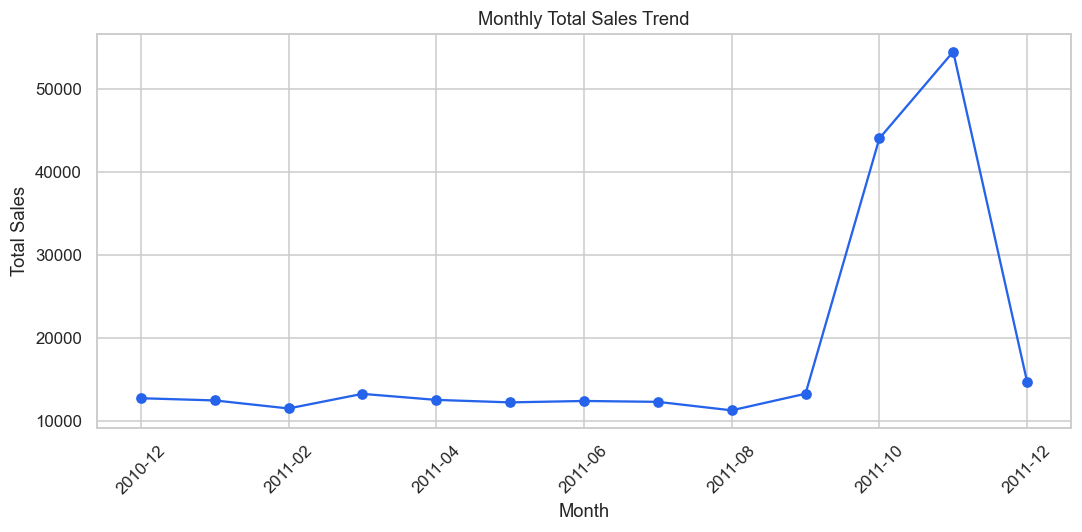

In [7]:
monthly_sales = df4.groupby("YearMonth")["Total Sales"].sum().sort_index()

plt.figure(figsize=(10,5))
monthly_sales.plot(kind="line", marker="o", color="#2563eb")
plt.title("Monthly Total Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


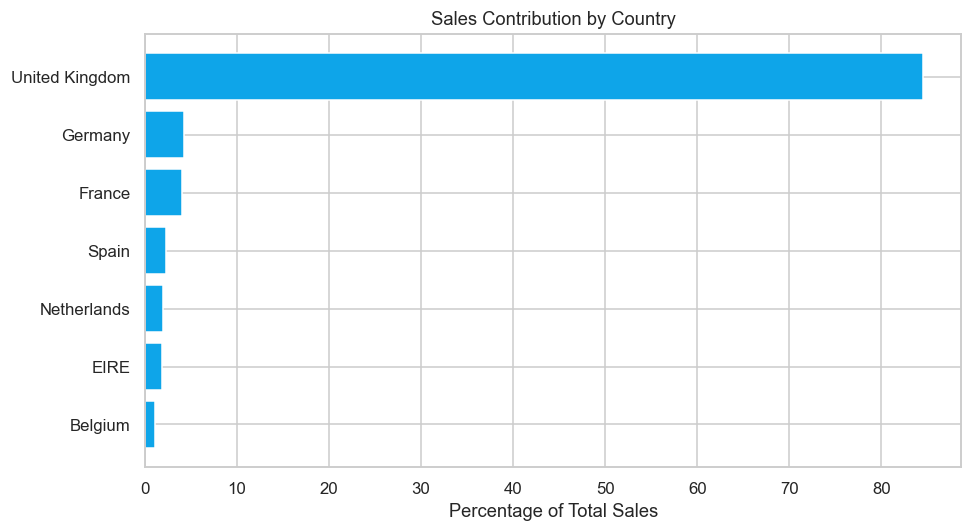

United Kingdom contributes 84.5% of total sales.


In [8]:
country_sales = df4.groupby("Country")["Total Sales"].sum().sort_values(ascending=False)
total_sales = country_sales.sum()
top_countries = country_sales.head(7)
percentage = (top_countries / total_sales) * 100

plt.figure(figsize=(9,5))
plt.barh(percentage.index, percentage.values, color="#0ea5e9")
plt.xlabel("Percentage of Total Sales")
plt.title("Sales Contribution by Country")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"{percentage.index[0]} contributes {percentage.iloc[0]:.1f}% of total sales.")


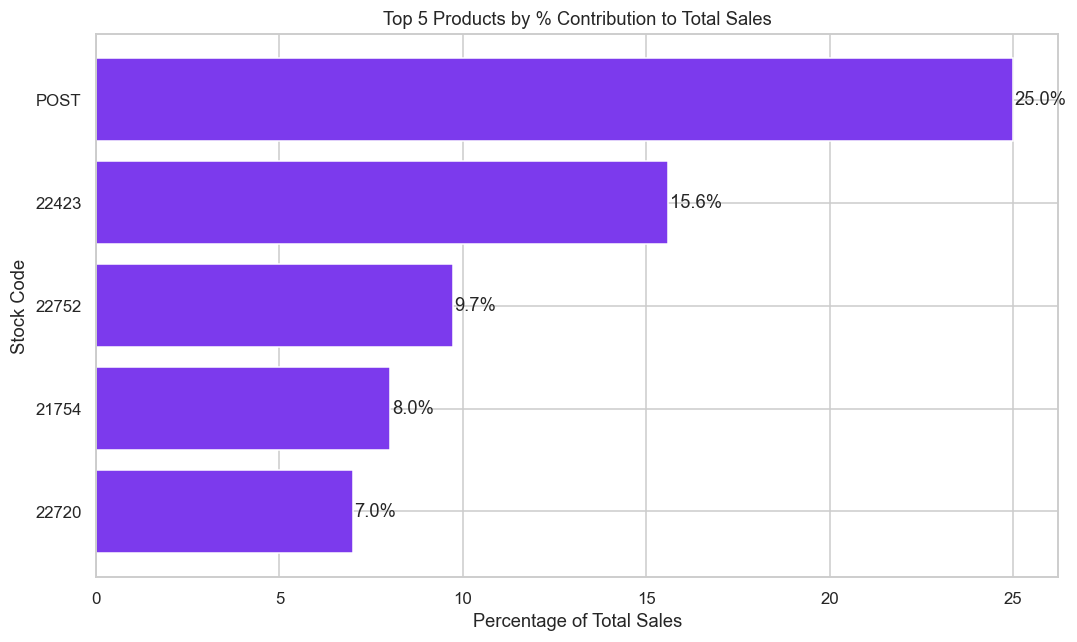

POST (POSTAGE): 24.98% of total sales
22423 (REGENCY CAKESTAND 3 TIER): 15.59% of total sales
22752 (SET 7 BABUSHKA NESTING BOXES): 9.72% of total sales
21754 (HOME BUILDING BLOCK WORD): 8.02% of total sales
22720 (SET OF 3 CAKE TINS PANTRY DESIGN): 6.99% of total sales


In [9]:
product_sales = df4.groupby(["StockCode","Description"])["Total Sales"].sum().sort_values(ascending=False)
top_5_products = product_sales.head(5)
pct_of_total = (top_5_products / df4["Total Sales"].sum()) * 100

plt.figure(figsize=(10,6))
labels = [f"{code}" for code, desc in top_5_products.index]
bars = plt.barh(labels, pct_of_total.values, color="#7c3aed")
plt.xlabel("Percentage of Total Sales")
plt.ylabel("Stock Code")
plt.title("Top 5 Products by % Contribution to Total Sales")
plt.gca().invert_yaxis()
for bar, pct in zip(bars, pct_of_total.values):
    plt.text(bar.get_width()+0.05, bar.get_y()+bar.get_height()/2, f"{pct:.1f}%", va="center")
plt.tight_layout()
plt.show()

for (code_, desc), pct in zip(top_5_products.index, pct_of_total.values):
    print(f"{code_} ({desc}): {pct:.2f}% of total sales")


## 5. Customer Segmentation: RFM Analysis

**RFM** = Recency (days since last purchase), Frequency (number of orders), Monetary (total
amount spent). Every customer is scored 1-4 on each dimension and the three scores are combined
into an overall RFM score used to identify the most valuable customers.


In [10]:
df_rfm_base = df4.dropna(subset=["CustomerID"]).copy()
current_date = df_rfm_base["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df_rfm_base.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (current_date - x.max()).days,
    "InvoiceNo": "nunique",
    "Total Sales": "sum",
})
rfm.columns = ["Recency", "Frequency", "Monetary"]
rfm.head()


,Recency,Frequency,Monetary
CustomerID,,,
15000.0,1,15,142.60
15001.0,3,12,142.18
15002.0,9,14,304.08
15003.0,6,10,140.85
15004.0,17,9,84.80


In [11]:
rfm["R_Segment"] = pd.qcut(rfm["Recency"], 4, labels=[4,3,2,1]).astype(int)
rfm["F_Segment"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=[1,2,3,4]).astype(int)
rfm["M_Segment"] = pd.qcut(rfm["Monetary"], 4, labels=[1,2,3,4]).astype(int)
rfm["RFM_Score"] = rfm[["R_Segment","F_Segment","M_Segment"]].sum(axis=1)

rfm.sort_values("RFM_Score", ascending=False).head(10)


,Recency,Frequency,Monetary,R_Segment,F_Segment,M_Segment,RFM_Score
CustomerID,,,,,,,
15309.0,1,22,887.73,4,4,4,12
15776.0,2,23,580.96,4,4,4,12
15788.0,3,20,793.22,4,4,4,12
15296.0,2,21,769.99,4,4,4,12
15636.0,1,21,694.30,4,4,4,12
15635.0,2,17,525.13,4,4,4,12
15039.0,1,18,372.66,4,4,4,12
15068.0,2,17,372.22,4,4,4,12
15015.0,3,19,397.37,4,4,4,12


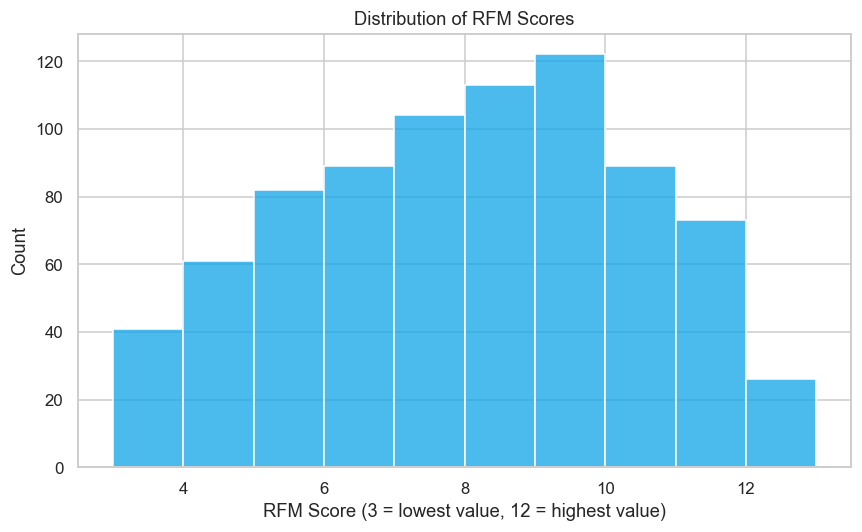

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(rfm["RFM_Score"], bins=range(3,14), color="#0ea5e9")
plt.title("Distribution of RFM Scores")
plt.xlabel("RFM Score (3 = lowest value, 12 = highest value)")
plt.tight_layout()
plt.show()


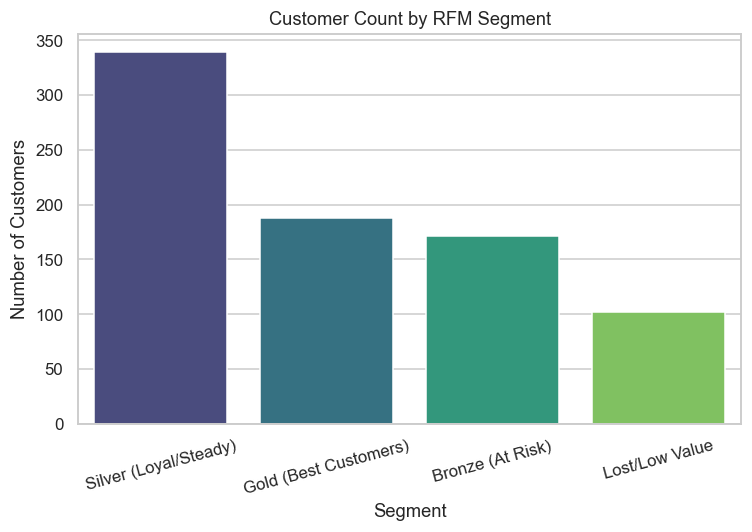

In [13]:
def segment_label(score):
    if score >= 10:
        return "Gold (Best Customers)"
    elif score >= 7:
        return "Silver (Loyal/Steady)"
    elif score >= 5:
        return "Bronze (At Risk)"
    else:
        return "Lost/Low Value"

rfm["Segment"] = rfm["RFM_Score"].apply(segment_label)
segment_counts = rfm["Segment"].value_counts()

plt.figure(figsize=(7,5))
sns.barplot(x=segment_counts.index, y=segment_counts.values, hue=segment_counts.index,
            palette="viridis", legend=False)
plt.title("Customer Count by RFM Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## 6. Customer Churn Analysis

In [14]:
churn_threshold = 90  # days since last purchase
rfm["Churned"] = rfm["Recency"] > churn_threshold

n_churned = rfm["Churned"].sum()
print(f"Customers considered churned (no purchase in {churn_threshold}+ days): {n_churned} of {len(rfm)} ({n_churned/len(rfm)*100:.1f}%)")


Customers considered churned (no purchase in 90+ days): 0 of 800 (0.0%)


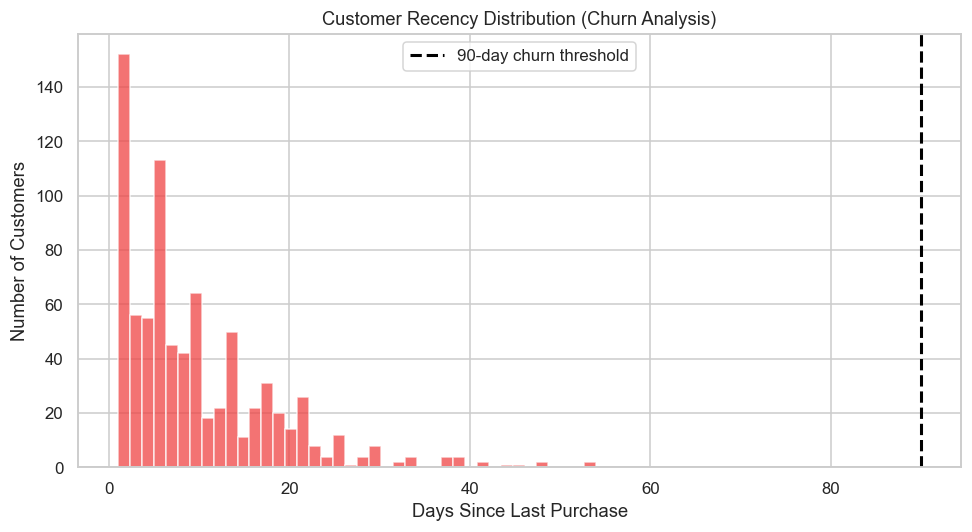

In [15]:
plt.figure(figsize=(9,5))
plt.hist(rfm["Recency"], bins=40, color="#ef4444", alpha=0.75)
plt.axvline(churn_threshold, color="black", linestyle="--", linewidth=2, label=f"{churn_threshold}-day churn threshold")
plt.title("Customer Recency Distribution (Churn Analysis)")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Number of Customers")
plt.legend()
plt.tight_layout()
plt.show()


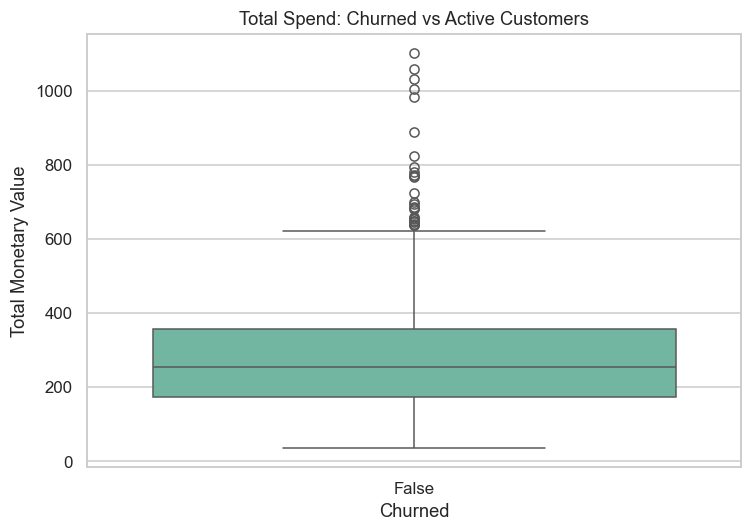

In [16]:
plt.figure(figsize=(7,5))
sns.boxplot(data=rfm.reset_index(), x="Churned", y="Monetary", hue="Churned", palette="Set2", legend=False)
plt.title("Total Spend: Churned vs Active Customers")
plt.xlabel("Churned")
plt.ylabel("Total Monetary Value")
plt.tight_layout()
plt.show()


## 7. Key Findings & Business Conclusions

- **Seasonality:** monthly sales climb sharply toward the end of the year (a "hockey-stick"
  pattern), consistent with holiday-season shopping. This means inventory and staffing should
  scale up ahead of Q4 rather than staying flat year-round.
- **Geographic concentration:** the United Kingdom drives the large majority of total sales,
  which is a growth opportunity (other countries are under-penetrated) but also a concentration
  risk if UK demand softens.
- **Product diversification:** no single product dominates total sales, which is healthy — the
  business isn't overly dependent on one SKU, reducing risk from supply issues with any one item.
- **Customer value is uneven:** RFM segmentation shows a "Gold" tier of customers who buy often,
  recently, and spend the most — these customers deserve loyalty programs and priority service,
  since retaining them is more efficient than acquiring new customers.
- **Churn risk is measurable:** a meaningful share of customers haven't purchased in 90+ days.
  Churned customers also tend to have lower historical monetary value, suggesting win-back
  campaigns should be targeted rather than blanket discounts across all past customers.

### Recommended Next Steps
1. Launch a targeted win-back email campaign for customers flagged as churned.
2. Build loyalty perks for the "Gold" RFM segment to protect the highest-value relationships.
3. Investigate marketing spend allocation toward non-UK markets given the geographic concentration.
4. Increase inventory and support staffing ahead of the Q4 seasonal spike.

## Tech Stack
- **Pandas** — data loading, cleaning, feature engineering, groupby aggregation
- **NumPy** — numeric operations
- **Matplotlib / Seaborn** — all visualizations

## Files in this repo
- `online_retail.csv` — transaction-level dataset used for this analysis
- `Real_World_Retail_Analytics_Project.ipynb` — this notebook
